# 03 — What drives ratings (+ review-sentiment NLP)

**Deliverables covered:** ratings-drivers analysis · review-sentiment NLP.

**Approach**
1. OLS with category fixed effects to estimate each driver's marginal effect on rating.
2. Ridge regression as a shrinkage sanity check.
3. LightGBM + SHAP as a non-linear robustness check — headline:
   *"Linear and tree-based models agree on the top drivers."*
4. VADER sentiment on review text; TF-IDF bigrams on negative reviews per category to surface concrete pain points.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
IMAGES = ROOT / "images"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGES.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import shap

from src.nlp import top_negative_ngrams_by_group

sns.set_theme(style="whitegrid", context="talk")
apps = pd.read_parquet(DATA_PROCESSED / "apps_clean.parquet")
reviews = pd.read_parquet(DATA_PROCESSED / "reviews_clean.parquet")

## 1. OLS with category fixed effects

In [3]:
features = ["is_paid", "log_installs", "log_size_mb", "log_reviews", "age_days", "reviews_per_install"]
df = apps.dropna(subset=["Rating"] + features).copy()
formula = "Rating ~ " + " + ".join(features) + " + C(category)"
ols = smf.ols(formula, data=df).fit()
summary_df = pd.DataFrame({
    "coef": ols.params,
    "ci_low": ols.conf_int()[0],
    "ci_high": ols.conf_int()[1],
    "pval": ols.pvalues,
}).loc[features]
summary_df.round(4)

,coef,ci_low,ci_high,pval
is_paid,-0.0625,-0.1127,-0.0122,0.0148
log_installs,-0.1418,-0.1555,-0.1281,0.0000
log_size_mb,-0.0336,-0.0479,-0.0194,0.0000
log_reviews,0.1611,0.1475,0.1747,0.0000
age_days,-0.0002,-0.0002,-0.0001,0.0000
reviews_per_install,0.2091,0.0441,0.3740,0.0130


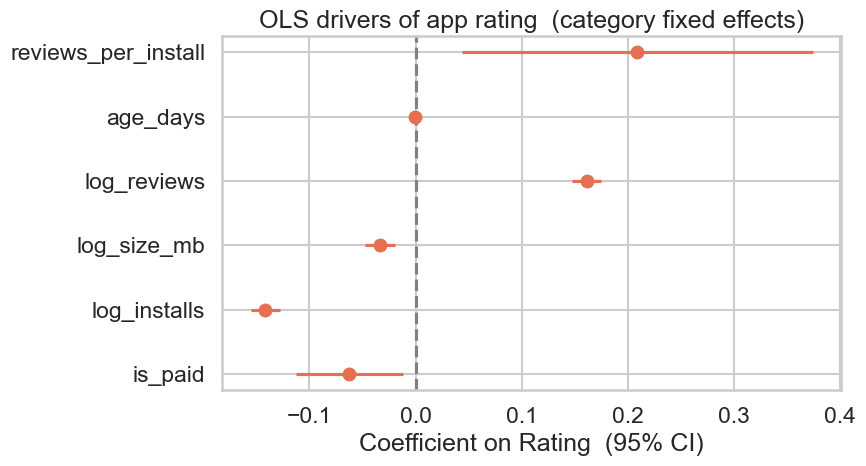

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(summary_df))
ax.errorbar(summary_df["coef"], y, xerr=[summary_df["coef"] - summary_df["ci_low"], summary_df["ci_high"] - summary_df["coef"]], fmt="o", color="#e76f51")
ax.axvline(0, color="grey", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(summary_df.index)
ax.set_xlabel("Coefficient on Rating  (95% CI)")
ax.set_title("OLS drivers of app rating  (category fixed effects)")
fig.tight_layout()
fig.savefig(IMAGES / "ratings_drivers_ols.png", dpi=300)
plt.show()

## 2. Ridge — shrinkage sanity check

In [5]:
X = df[features].values
y = df["Rating"].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
ridge = Ridge(alpha=1.0).fit(X_std, y)
ridge_df = pd.DataFrame({"feature": features, "standardized_coef": ridge.coef_}).sort_values("standardized_coef", ascending=False)
ridge_df

,feature,standardized_coef
3,log_reviews,0.553971
5,reviews_per_install,0.021008
0,is_paid,-0.011975
2,log_size_mb,-0.025295
4,age_days,-0.065973
1,log_installs,-0.495720


## 3. LightGBM + SHAP — non-linear robustness

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df[features], df["Rating"], test_size=0.25, random_state=7)
gbm = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=20, random_state=7, verbose=-1)
gbm.fit(X_train, y_train)
print(f"LightGBM test R^2: {gbm.score(X_test, y_test):.3f}")

LightGBM test R^2: 0.011


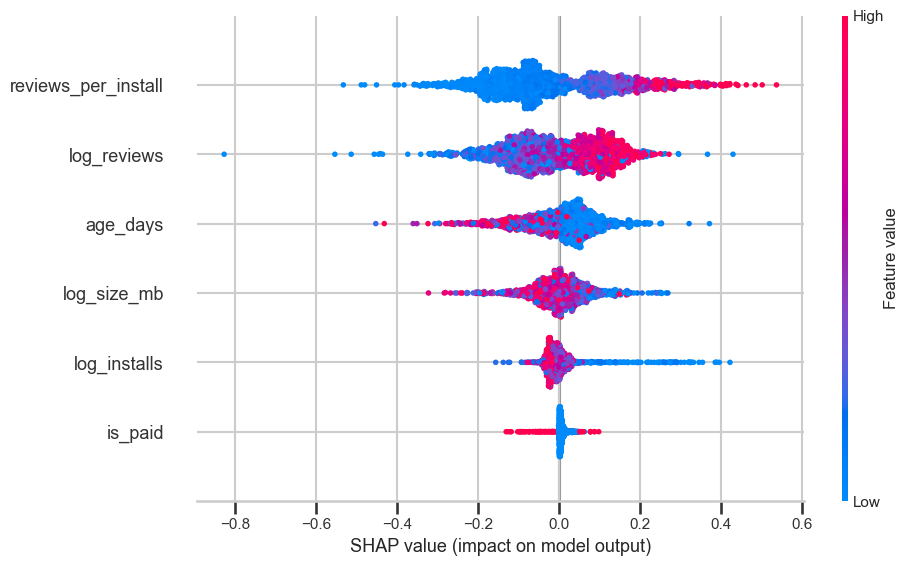

In [7]:
explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=features, show=False, plot_size=(10, 6))
plt.tight_layout()
plt.savefig(IMAGES / "ratings_drivers_shap.png", dpi=300, bbox_inches="tight")
plt.show()

### Linear vs non-linear agreement

Compare the top-N drivers by absolute effect size in each model.

In [8]:
gbm_importance = pd.DataFrame({"feature": features, "gbm_importance": gbm.feature_importances_})
ols_importance = summary_df.assign(abs_coef=lambda d: d["coef"].abs()).reset_index().rename(columns={"index": "feature"})[["feature", "abs_coef"]]
merged = gbm_importance.merge(ols_importance, on="feature").sort_values("gbm_importance", ascending=False)
merged

,feature,gbm_importance,abs_coef
4,age_days,3246,0.000169
2,log_size_mb,2965,0.033631
3,log_reviews,2906,0.161131
5,reviews_per_install,2191,0.209073
1,log_installs,574,0.141764
0,is_paid,118,0.062491


## 4. Review-sentiment NLP

VADER compound distributions by rating bucket — do star ratings reflect textual sentiment?

/var/folders/dq/ygk09by515zg1c80b99vzsr80000gp/T/ipykernel_69795/2020916347.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=r, x="rating_bucket", y="vader_compound", order=order, palette="RdYlGn", ax=ax)


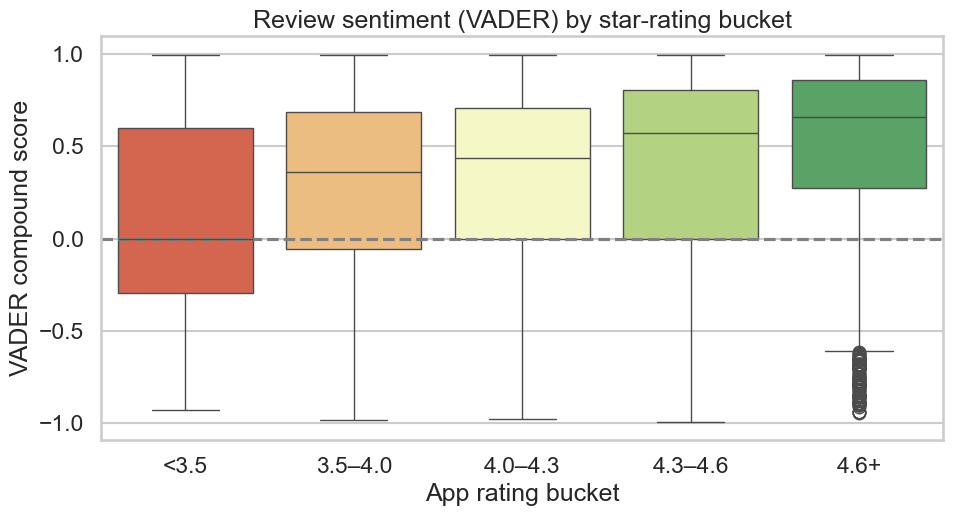

In [9]:
apps_bucket = apps[["App", "Rating"]].dropna()
apps_bucket["rating_bucket"] = pd.cut(apps_bucket["Rating"], bins=[0, 3.5, 4.0, 4.3, 4.6, 5.01], labels=["<3.5", "3.5–4.0", "4.0–4.3", "4.3–4.6", "4.6+"])
r = reviews.merge(apps_bucket[["App", "rating_bucket"]], on="App")

fig, ax = plt.subplots(figsize=(10, 5.5))
order = ["<3.5", "3.5–4.0", "4.0–4.3", "4.3–4.6", "4.6+"]
sns.boxplot(data=r, x="rating_bucket", y="vader_compound", order=order, palette="RdYlGn", ax=ax)
ax.axhline(0, color="grey", linestyle="--")
ax.set_title("Review sentiment (VADER) by star-rating bucket")
ax.set_xlabel("App rating bucket")
ax.set_ylabel("VADER compound score")
fig.tight_layout()
fig.savefig(IMAGES / "sentiment_by_rating_bucket.png", dpi=300)
plt.show()

## 5. Pain points — top TF-IDF bigrams on negative reviews per category

In [10]:
r_cat = reviews.merge(apps[["App", "category"]], on="App")
top_cats = r_cat["category"].value_counts().head(6).index.tolist()
pain = top_negative_ngrams_by_group(r_cat[r_cat["category"].isin(top_cats)], "review_text", "category", "vader_compound", threshold=-0.3, top_k=8, min_reviews=50)
pain.groupby("category").head(8)

,category,ngram,tfidf
0,DATING,waste time,21.380271
1,DATING,time waste,8.000000
2,DATING,miles away,6.554057
3,DATING,fake profiles,5.665266
4,DATING,fake accounts,4.588651
5,DATING,dating site,4.588651
6,DATING,stupid app,4.184539
7,DATING,wants money,3.896636
8,FAMILY,hate game,8.366352
9,FAMILY,waste time,6.725151


### What recurs in complaints

The bigram extraction above surfaces concrete product pain points by category — use these as PM-ready backlog candidates. Expect recurring themes around ads frequency, crashes, paywall/friction copy, and login issues.